# Author profiling

Author profiling is a supervised clasification technique to identify demographic characteristics of an objective group. In this task, given the text of a Twitter feed, we'll determine the authors nationality.

To accomplish this task we'll implement a hierarchical attention RNN based on the one presented in
https://aclanthology.org/N16-1174.pdf

The RNN main structure consists of a continuos word and sentence attention module, with classification and normalization layers in between.


## 1. Dataset exploration

We are given one html file with several tweets for each author and a txt file with the corresponding labels.

First we use beautiful soup to put together all files.

In [ ]:
import glob
from bs4 import BeautifulSoup
import os

#os.getcwd()

def read_data(path):
    authors = {}

    # Read truth file
    truth = {}
    with open(path +'truth.txt', 'r', encoding='utf-8') as file:
        for line in file:
            parts = line.strip().split(':::')
            if len(parts) == 3:
                author_id, gender, nationality = parts
                truth[author_id] = {'gender': gender, 'nationality': nationality}

    # Iterate over all xml
    for author in glob.glob(path+"*"):
        try:
            with open(author, "r", encoding="utf-8") as file:
                soup = BeautifulSoup(file.read(), 'html')
            tweets = [doc.get_text() for doc in soup.find_all('document')]

            author_id = os.path.splitext(os.path.basename(author))[0]
            
            labels = truth.get(author_id, {'gender': None, 'nationality': None})

            authors[author_id] = {
                'tweets': tweets,
                'gender': labels['gender'],
                'nationality': labels['nationality']
            }

        except Exception as e:
            print(f"Error while processing {author}: {e}")

    return authors


In [ ]:
import pickle
    
train_authors=read_data("es_train/")
val_authors=read_data("es_val/")


In [19]:
import pandas as pd

rows = []
for author_id, info in train_authors.items():
    row = {
        'author': author_id,
        'tweets': info['tweets'],
        'gender': info['gender'],
        'nationality': info['nationality']
    }
    rows.append(row)

df_train = pd.DataFrame(rows)
print(df_train.head())


                             author  \
0  1011b55a13502bcb7562d610a05ef3bd   
1  1026000a7c186f3a4aba1053f9956b42   
2  1032e9d0da6d21ceab370759d38930a9   
3  10880d19d7346373a42b18e505bbc4d5   
4  10aef88d048dafbc75639241b9e35df8   

                                              tweets  gender nationality  
0  [#4FRebelionDePatriotas Rebelión Cívico-Milita...    male   venezuela  
1  [Mongodoy es un pobre diablo, un dia nos sorpr...    male        peru  
2  [Que buen orador es Eduardo Torres Dulce. Es c...    male       spain  
3  [Nueva orden ejecutiva de Trump también afecta...  female   venezuela  
4  [Me gustó un video de @YouTube https://t.co/tA...  female      mexico  


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string

def analyze_tweets_statistics(df_train):
    """
    Analyze various statistics from the df_train DataFrame and plot histograms.
    Includes number of tweets per user, average tweet length, gender/nationality proportions,
    and proportion of punctuation and stopwords in tweets.
    """
    tokenizer=TweetTokenizer()
    # Initialize English and Spanish stopword
    stop_words = set(stopwords.words('spanish'))
    punctuation = set(string.punctuation)

    # Total number of authors
    num_authors = df_train['author'].nunique()
    print(f"Total number of authors: {num_authors}")

    # Number of tweets per author
    df_train['num_tweets'] = df_train['tweets'].apply(len)
    plt.figure(figsize=(8,6))
    sns.histplot(df_train['num_tweets'], bins=20, kde=False)
    plt.title('Number of tweets per author')
    plt.xlabel('Number of tweets')
    plt.ylabel('Frequency')
    plt.show()

    # Average tweet length per author (in characters)
    def avg_tweet_length(tweets):
        lengths = [len(tweet) for tweet in tweets]
        return sum(lengths) / len(lengths) if lengths else 0

    df_train['avg_tweet_length'] = df_train['tweets'].apply(avg_tweet_length)
    plt.figure(figsize=(8,6))
    sns.histplot(df_train['avg_tweet_length'], bins=20, kde=False)
    plt.title('Average tweet length per author')
    plt.xlabel('Average length (characters)')
    plt.ylabel('Frequency')
    plt.show()

    # Gender proportion
    plt.figure(figsize=(6,4))
    df_train['gender'].value_counts(normalize=True).plot(kind='bar')
    plt.title('Gender proportion')
    plt.ylabel('Proportion')
    plt.show()

    # Nationality proportion
    plt.figure(figsize=(10,4))
    df_train['nationality'].value_counts(normalize=True).plot(kind='bar')
    plt.title('Nationality proportion')
    plt.ylabel('Proportion')
    plt.show()

    # Tokenize each tweet, compute punctuation and stopword proportion per author
    def compute_ratios(tweets):
        total_tokens = 0
        punct_count = 0
        stopword_count = 0

        for tweet in tweets:
            tokens = tokenizer.tokenize(tweet.lower())
            total_tokens += len(tokens)
            punct_count += sum(1 for t in tokens if t in punctuation)
            stopword_count += sum(1 for t in tokens if t in stop_words)

        punct_ratio = punct_count / total_tokens if total_tokens else 0
        stopword_ratio = stopword_count / total_tokens if total_tokens else 0

        return pd.Series({'punct_ratio': punct_ratio, 'stopword_ratio': stopword_ratio})

    ratios = df_train['tweets'].apply(compute_ratios)
    df_train = pd.concat([df_train, ratios], axis=1)

    # Plot punctuation ratio histogram
    plt.figure(figsize=(8,6))
    sns.histplot(df_train['punct_ratio'], bins=20, kde=False)
    plt.title('Punctuation ratio per author')
    plt.xlabel('Proportion of punctuation tokens')
    plt.ylabel('Frequency')
    plt.show()

    # Plot stopword ratio histogram
    plt.figure(figsize=(8,6))
    sns.histplot(df_train['stopword_ratio'], bins=20, kde=False)
    plt.title('Stopword ratio per author')
    plt.xlabel('Proportion of stopwords tokens')
    plt.ylabel('Frequency')
    plt.show()

    return df_train  # return enriched DataFrame if you want to keep new columns

# Usage:
# enriched_df = analyze_tweets_statistics(df_train)


Total number of authors: 3361


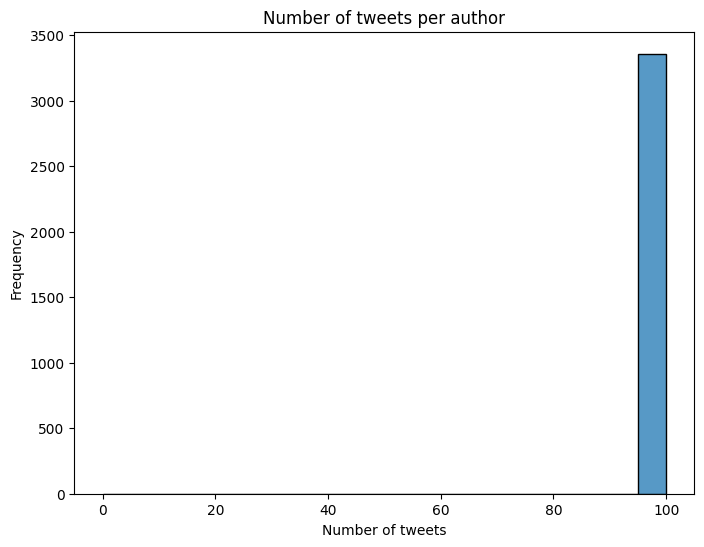

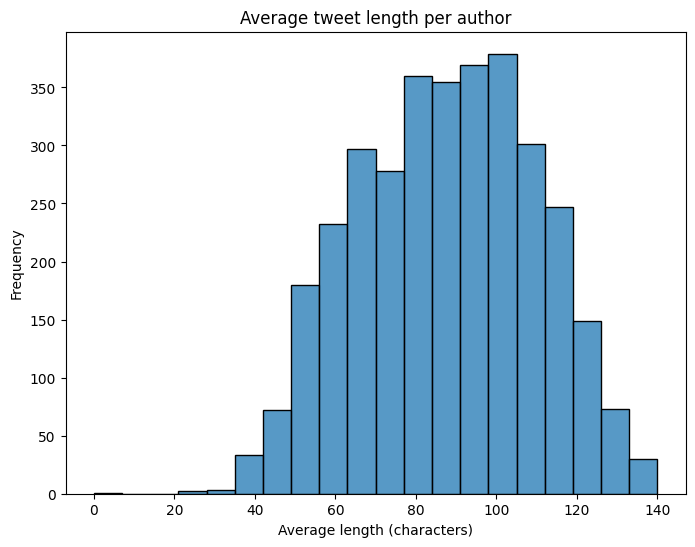

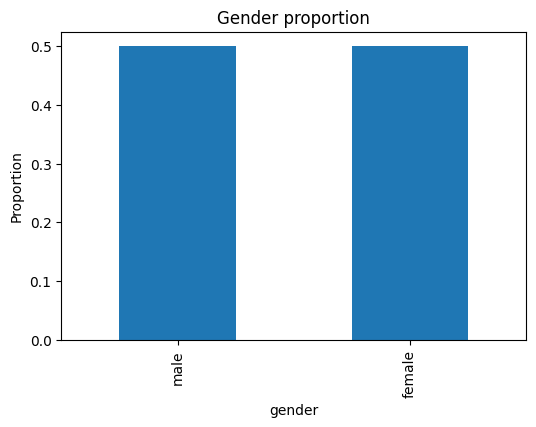

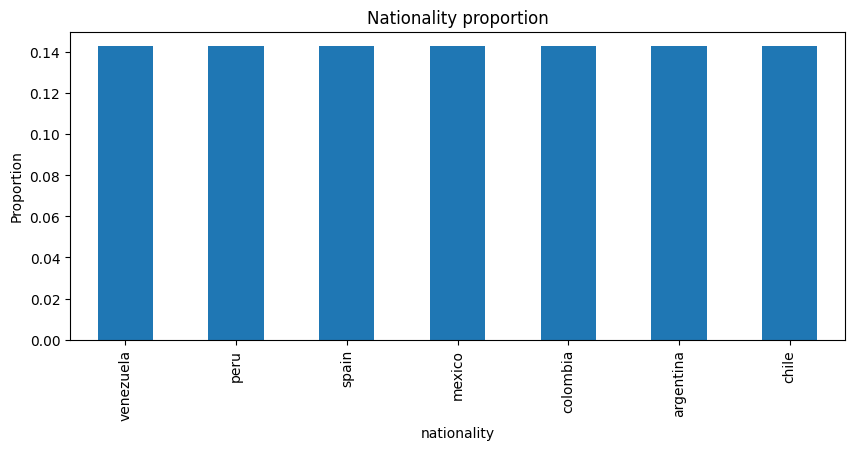

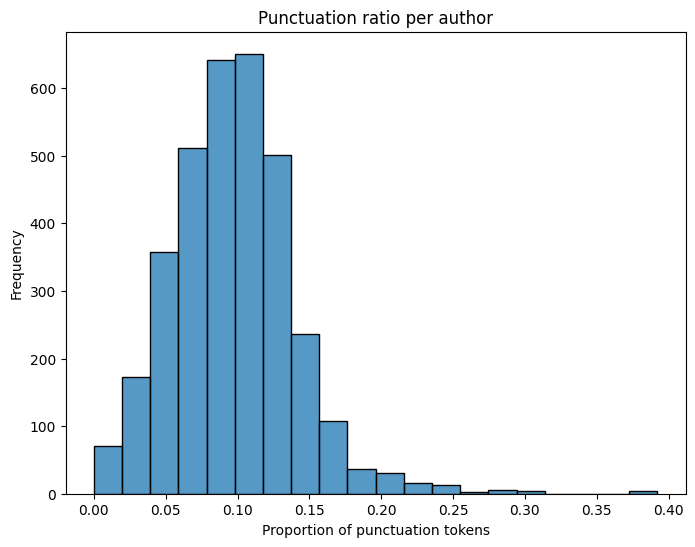

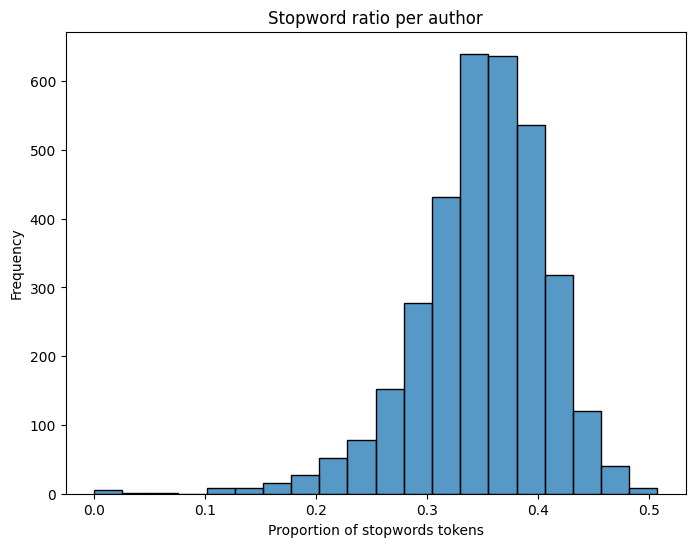

In [ ]:
df_train_augmented=analyze_tweets_statistics(df_train)

With the previous analysis we notice that the training set is balanced. There are 3,500 authors with 100 tweets each. Moreover, each tweet length is more frequently between 80 to 100 tokens. Close to 10% of the tokens are punctuation characters and around 35% of them are stop words.

In the following, we will care only about profiling nationality. To figure if its valuable to keep stop words and punctuation characters, we will group each nationality and revise the proportion of both characteristics across groups.

In [46]:
nationalities = df_train['nationality'].unique()
nationalities[:-1]

array(['venezuela', 'peru', 'spain', 'mexico', 'colombia', 'argentina',
       'chile'], dtype=object)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import entropy, gaussian_kde

def plot_ratios_by_nationality_grid_and_kde_with_kl(df):
    """
    Plot histograms and KDEs of punct_ratio and stopword_ratio by nationality,
    and compute KL-divergence between each pair of nationalities, visualized as a heatmap.
    """
    nationalities = df['nationality'].unique()[:-1]
    nationalities

    for ratio_col in ['punct_ratio', 'stopword_ratio']:
        # Plot grid of histograms
        plt.figure(figsize=(20, 10))
        plt.suptitle(f'Histograms of {ratio_col} by nationality', fontsize=16)

        for idx, nat in enumerate(nationalities):
            plt.subplot(2, 4, idx + 1)
            subset = df[df['nationality'] == nat]
            sns.histplot(subset[ratio_col], bins=20, kde=False)
            plt.title(f'{nat}')
            plt.xlabel(ratio_col)
            plt.ylabel('Frequency')

        # Hide empty subplots if fewer than 8 nationalities
        total_plots = 8
        if len(nationalities) < total_plots:
            for idx in range(len(nationalities), total_plots):
                plt.subplot(2, 4, idx + 1)
                plt.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

        # Compute KDE on a common grid for each nationality
        grid = np.linspace(0, 1, 1000)
        kde_dict = {}

        plt.figure(figsize=(10, 6))
        plt.title(f'KDE of {ratio_col} by nationality')

        for nat in nationalities:
            subset = df[df['nationality'] == nat][ratio_col].dropna()
            if len(subset) > 1:
                kde = gaussian_kde(subset, bw_method=0.2)  # adjust bw_method if needed
                y = kde(grid)
                y /= y.sum()  # normalize to sum=1
                kde_dict[nat] = y
                plt.plot(grid, y, label=nat)
            else:
                y = np.ones_like(grid) / len(grid)
                kde_dict[nat] = y
                plt.plot(grid, y, label=nat)

        plt.xlabel(ratio_col)
        plt.ylabel('Density')
        plt.legend(title='Nationality')
        plt.show()

        # Compute KL-divergence matrix
        kl_matrix = np.zeros((len(nationalities), len(nationalities)))

        for i, nat_i in enumerate(nationalities):
            for j, nat_j in enumerate(nationalities):
                p = kde_dict[nat_i] + 1e-10  # avoid log(0)
                q = kde_dict[nat_j] + 1e-10
                kl = entropy(p, q)
                kl_matrix[i, j] = kl

        # Plot heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(kl_matrix, xticklabels=nationalities, yticklabels=nationalities, annot=True, cmap='viridis')
        plt.title(f'KL-divergence between nationalities for {ratio_col}')
        plt.xlabel('Nationality Q')
        plt.ylabel('Nationality P')
        plt.show()


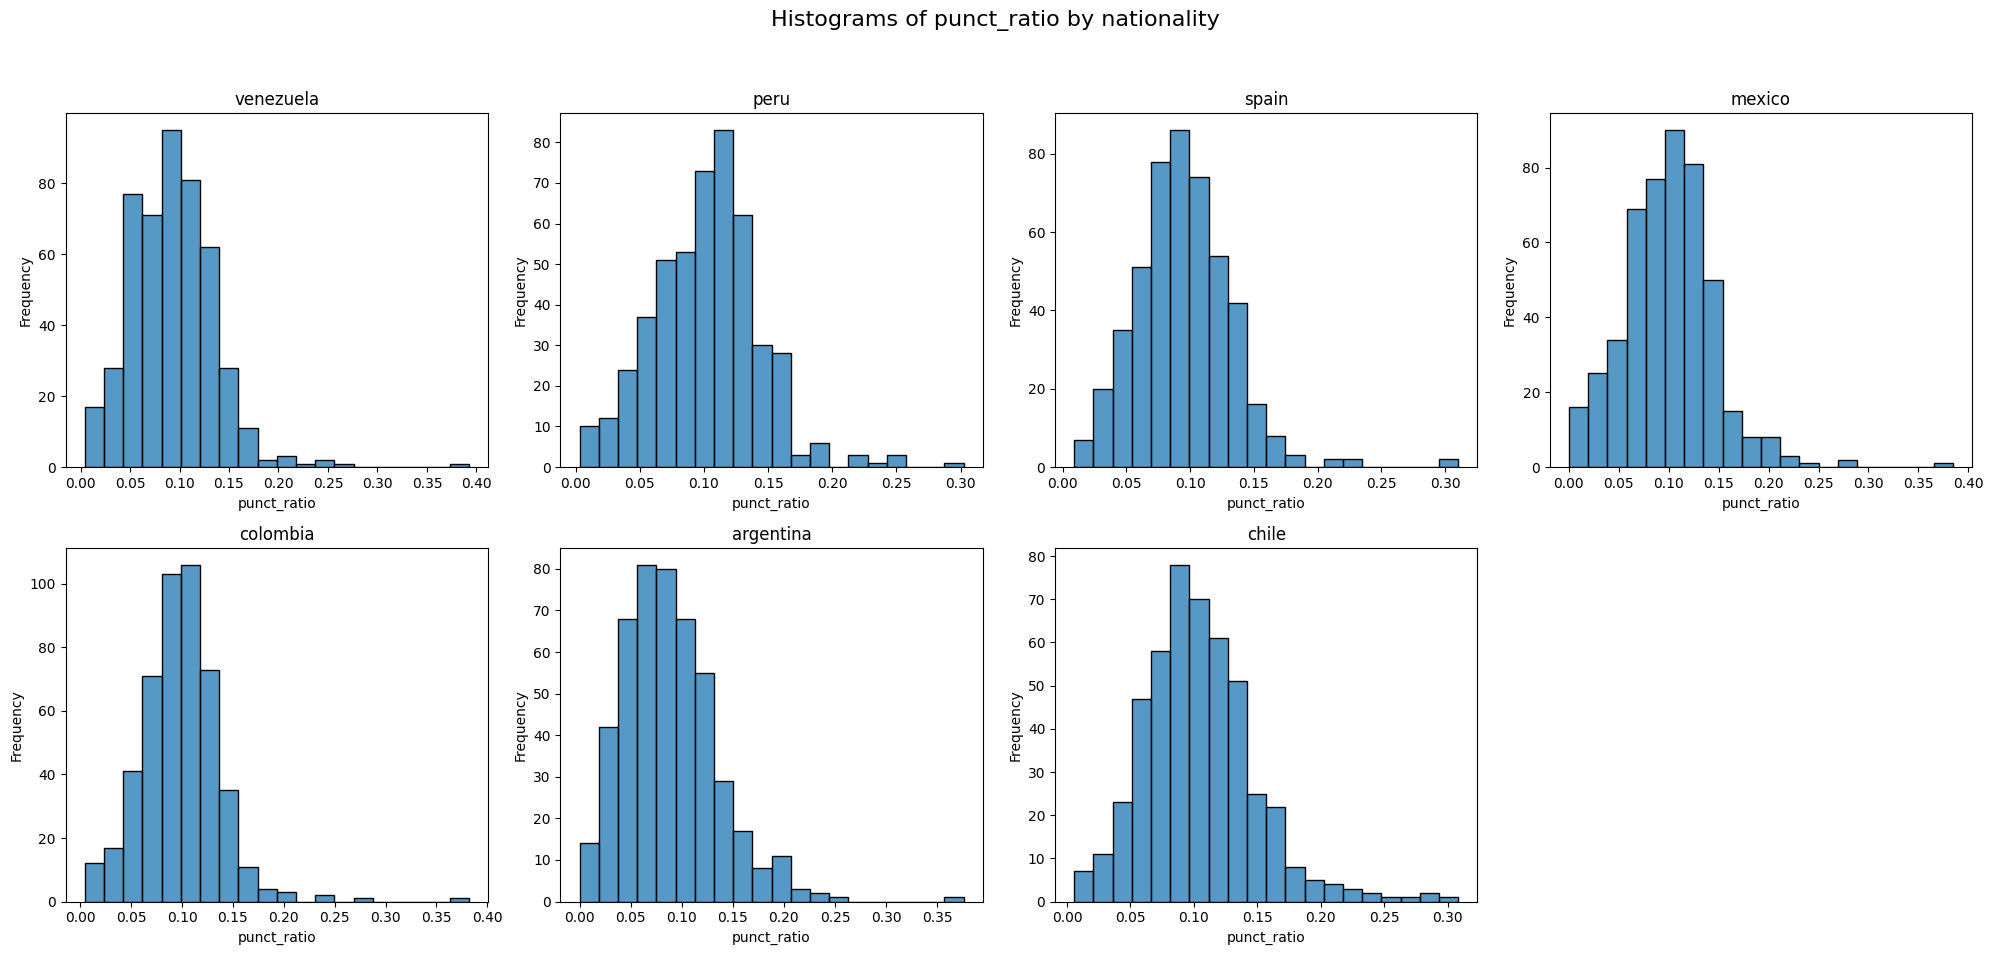

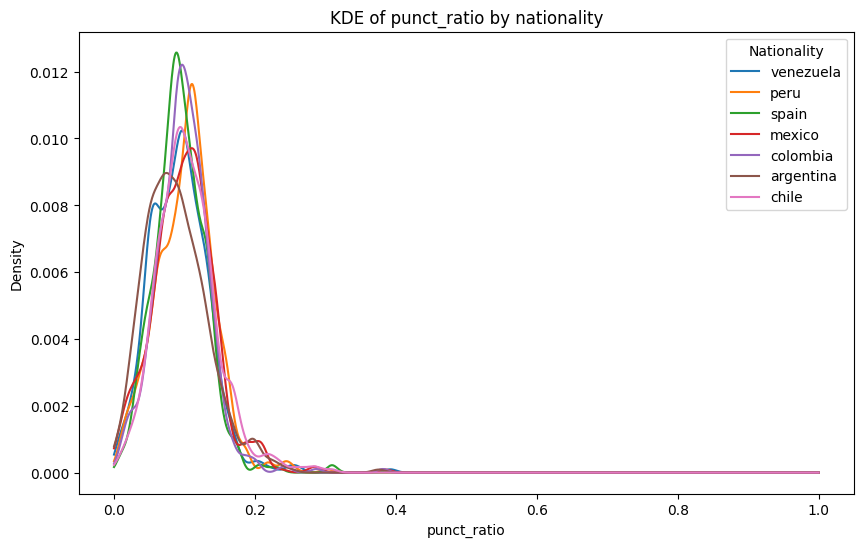

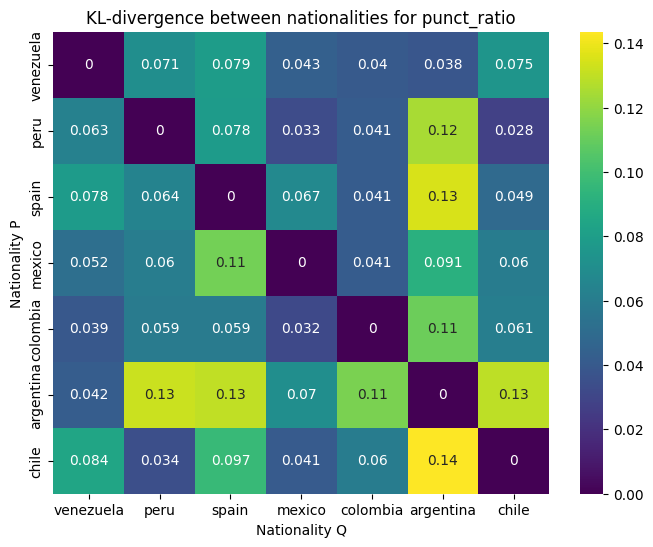

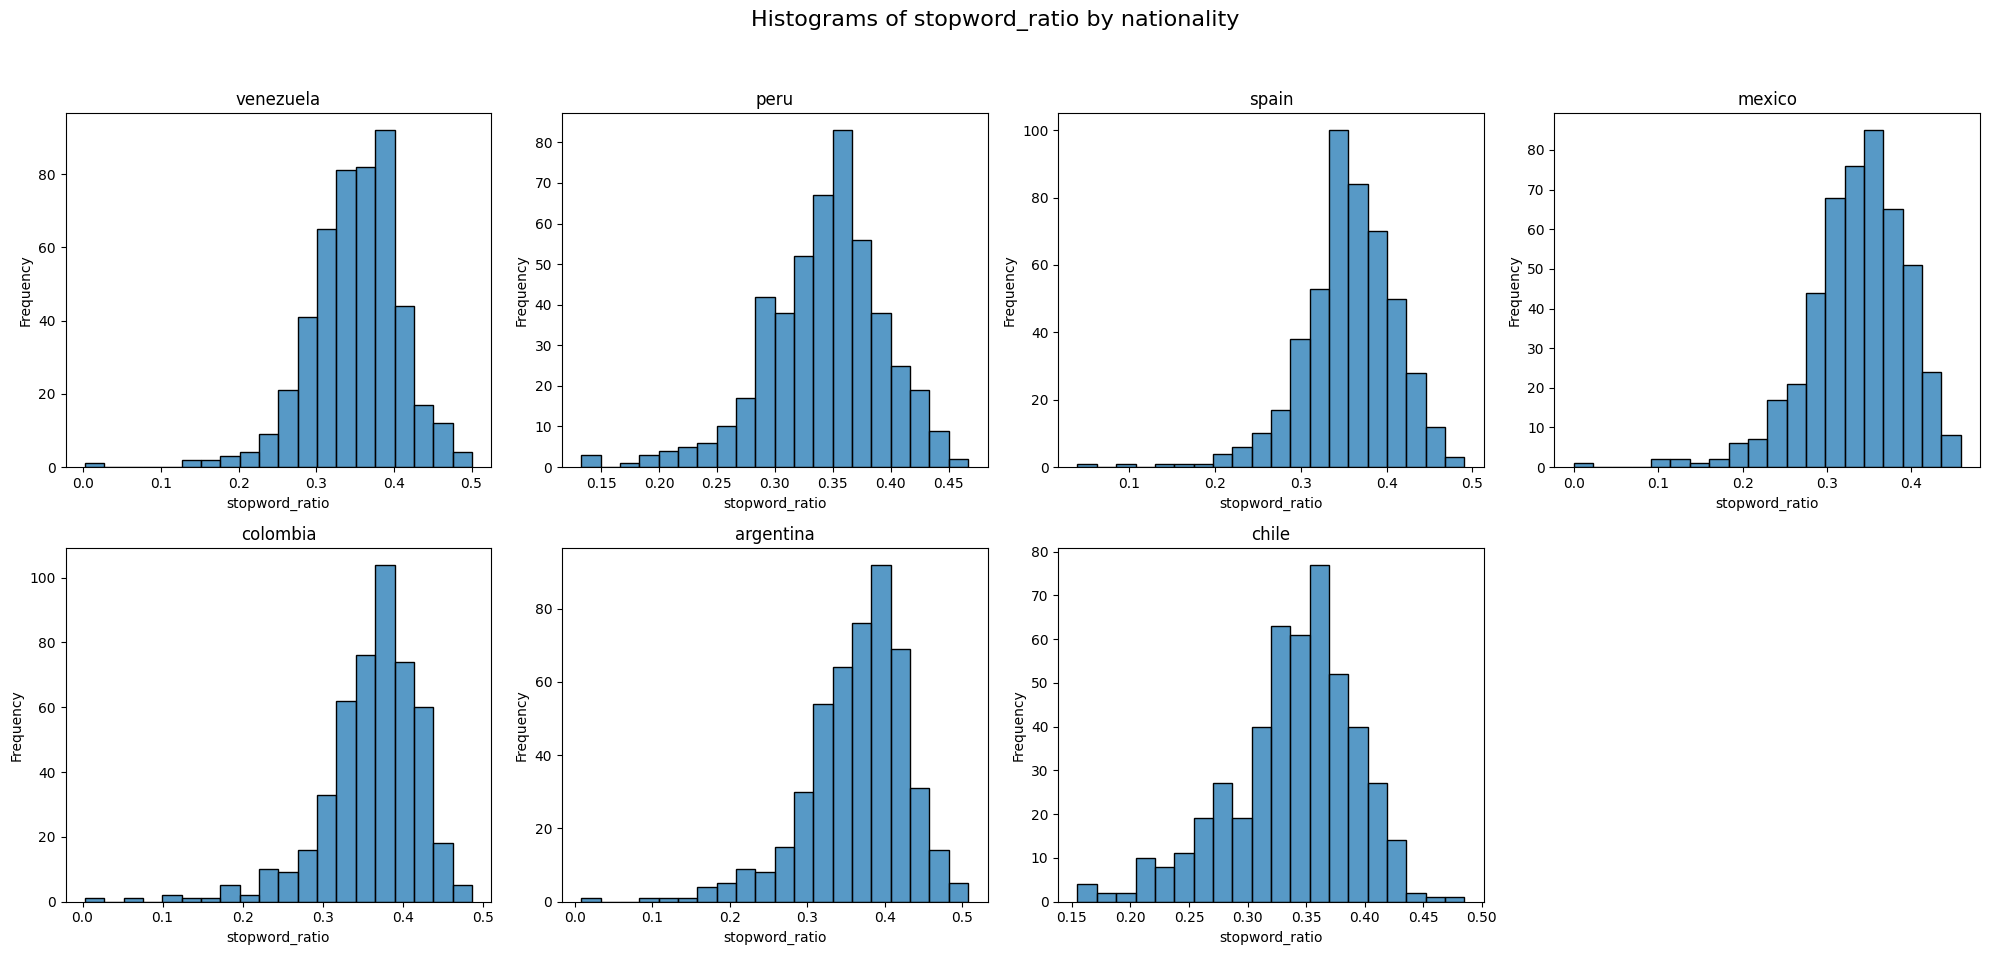

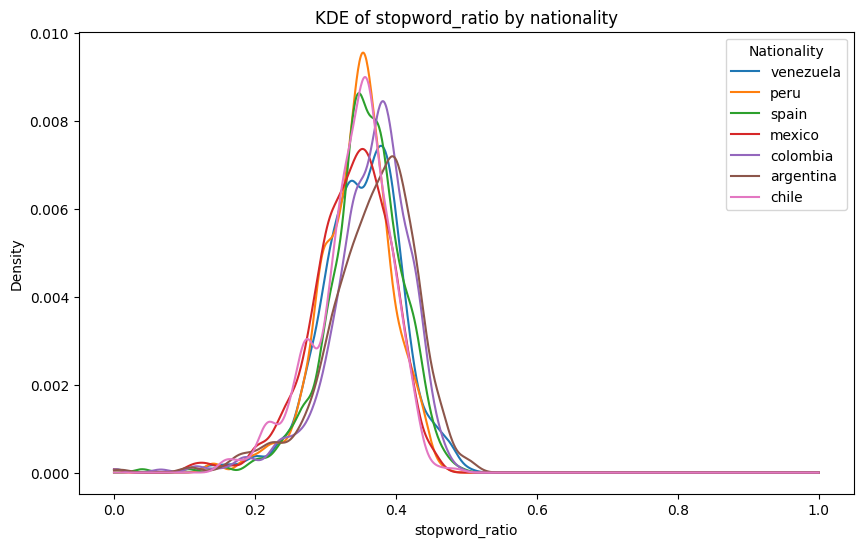

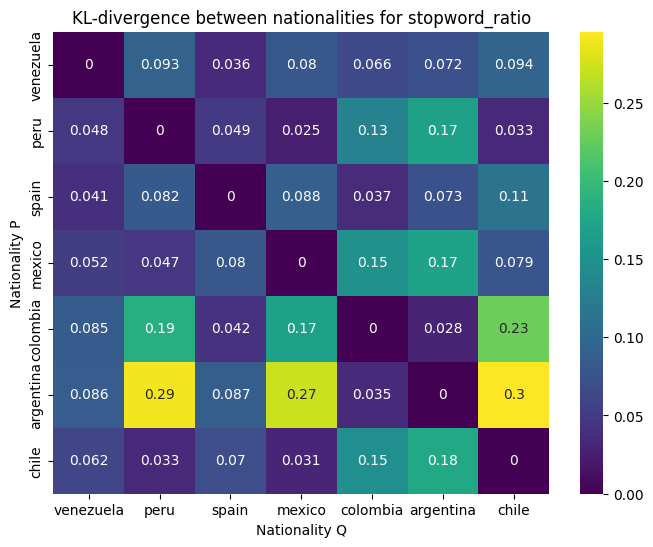

In [50]:
plot_ratios_by_nationality_grid_and_kde_with_kl(df_train_augmented)

There seems to be some distance between some nationalitys with respect to the punctuation and stop words distribution. This distance is greater for stopwords. The difference is relatively small, but the model with attention may capture characteristics within other style feature involving both characteristics.

It's a trade-off, more tokens included in the attention and RNN or less tokens with additional style indicators.

## 2. Data processing and RNN construction

In [1]:
import pandas as pd
import pickle
import numpy as np
import nltk
#nltk.download('punkt')
#nltk.download('punkt_tab')
from tqdm.auto import tqdm
import copy
from collections import Counter
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pad_packed_sequence, pack_padded_sequence
import torch.nn.functional as F
from nltk import TweetTokenizer
from sklearn.metrics import f1_score

c:\Users\disom\OneDrive\CIMAT\python_code\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [61]:
import re
import string
from nltk.tokenize import TweetTokenizer

def remove_urls(text):
    return re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)

def remove_emojis(text):
    emoji_pattern = re.compile(
        "[" 
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002700-\U000027BF"  # dingbats
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def preprocess_text(text):
    text = text.lower()
    text = remove_urls(text)
    text = remove_emojis(text)
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text)

    # Remove punctuation tokens using NLTK/standard punctuation list
    tokens = [token for token in tokens if token not in string.punctuation]

    return tokens

def preprocess_data(raw_dict):
    """
    Cleans and tokenizes tweets from a raw author-based dictionary.
    Adds a 'target' field with numeric encoding of nationality.
    Returns: author_id → {'tweets': [...], 'gender': ..., 'nationality': ..., 'target': int}
    """
    cleaned_dict = {}

    # Map nationality to an integer index
    nationality_to_index = {
        'argentina': 0,
        'chile': 1,
        'colombia': 2,
        'mexico': 3,
        'peru': 4,
        'spain': 5,
        'venezuela': 6
    }

    for author_id, info in raw_dict.items():
        try:
            nat = info['nationality']
            if nat not in nationality_to_index:
                continue  # skip if nationality is unknown or None

            cleaned_tweets = [preprocess_text(tweet) for tweet in info['tweets']]
            cleaned_dict[author_id] = {
                'tweets': cleaned_tweets,
                'gender': info['gender'],
                'nationality': nat,
                'target': nationality_to_index[nat]
            }
        except Exception as e:
            print(f"Error processing author {author_id}: {e}")
    
    return cleaned_dict



In [62]:
clean_train_authors=preprocess_data(train_authors)
clean_val_authors=preprocess_data(val_authors)

# Guardar
with open('train_dict.pkl', 'wb') as f:
    pickle.dump(clean_train_authors, f)
    
# Guardar
with open('val_dict.pkl', 'wb') as f:
    pickle.dump(clean_val_authors, f)    
    
#clean_train_authors

In [ ]:
k=0
with open('word2vec_col/word2vec_col.txt', 'r') as f:
            for i, line in enumerate(f):
                k+=1
                values = line.split()
                
                print(values[0])
                print(np.asarray(values[1:], "float32"))
                #print(len(np.asarray(values[1:], "float32")))
                if k==2:
                    break
                

973265
[100.]
1
de
[-1.64168   1.447671 -2.283216 -1.965226 -0.222943  5.105217 -0.120701
 -0.126822 -3.177338 -3.454396 -0.943083 -0.094476 -1.18936  -0.812092
 -2.572975 -0.613877 -2.311841  1.05097   5.634725 -5.827006  1.237639
  1.071621  3.822072  2.395414  0.169883  3.256835  2.897348  3.274827
 -2.936382  0.272003 -1.029505 -2.617288 -1.807143  1.737624  0.33913
  3.93293   1.571361 -4.100074  4.156816  1.162366 -0.552316 -0.585887
 -4.767187  0.253338 -1.124162 -0.115079 -5.606624  2.976579  4.426022
  1.019932  3.76072  -2.298347  4.416567 -1.383988 -1.862506  0.399053
 -1.09689  -2.28599   2.992802  0.044008  3.762375 -6.523126  0.621278
  2.641829 -1.924327 -1.141184 -3.831767  0.549591  2.260839 -1.318358
 -1.134662 -3.788221 -0.775024  3.956695 -3.579425 -4.423733  4.505686
  0.719133 -1.399557  3.097209  0.107541  2.829867 -0.760249 -0.277246
 -1.225739  2.157902  0.518391  3.437977 -1.087452 -1.529914  0.399476
  0.887398 -1.994891  2.912205  3.257981 -2.599953 -1.99513

In [34]:
a= ["a",[[1,2,3],[4,5,6],[7,8,9]],"b"]
z= a[2]

word_ids = [torch.tensor(t) for t in a[1]]
print(word_ids)
word_ids = torch.cat(word_ids, dim=0)
print(word_ids)
lengths = torch.tensor([len(t) for t in a[1]])
print(lengths)
print(a[1][2])

[len(tweet) for tweet in a[1]]


[tensor([1, 2, 3]), tensor([4, 5, 6]), tensor([7, 8, 9])]
tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([3, 3, 3])
[7, 8, 9]


[3, 3, 3]

In [2]:
class TweetDataset(Dataset):
    def __init__(self, split):
        super(Dataset, self).__init__()
        #Load data
        self.load_data(split)

        self.vocab, self.emb_mat = self.load_vocab_embeddings()

    def load_data(self, split):
        '''Loads author-level data from .pkl file.'''
        with open(split+'.pkl', 'rb') as f:
            dic_data=pickle.load(f)
        
        rows =[]   
        for author_id, info in dic_data.items():
            row = {
                'author': author_id,
                'tweets': info['tweets'],
                'gender': info['gender'],
                'nationality': info['nationality'],
                'target': info['target']
            }
            rows.append(row)
        
        self.data = pd.DataFrame(rows) 
        
    def __len__(self):
        return len(self.data)
    
    def load_vocab_embeddings(self):
        '''Loads pre-trained embeddings and constructs vocabulary.'''
        embeddings_list = []
        self.vocab_dict = {}
        vocab = {}
        with open('word2vec_col/word2vec_col.txt', 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    self.vocab_dict[i+1] = values[0]
                    vocab[values[0]] = i+1
                    vector = np.asarray(values[1:], dtype='float32')
                    embeddings_list.append(vector)

        # Use average vector and zero padding
        mean_vector = np.mean(np.vstack(embeddings_list), axis=0)
        embeddings_list.insert(0, mean_vector)
        embeddings_list.insert(0, np.zeros_like(mean_vector))

        self.vocab_dict[0] = '[PAD]'
        self.vocab_dict[1] = '[UNK]'
        vocab['[PAD]'] = 0
        vocab['[UNK]'] = 1

        emb_mat = np.vstack(embeddings_list)
        return vocab, emb_mat

    def preprocessed_text(self, index):
        '''Obtain word ID for words in tweets, text is already tokenized'''

        tweets = self.data.iloc[index]['tweets']  # list of tokenized tweets
        tweet_ids = []
        for tweet in tweets:
            ids = [self.vocab.get(word, self.vocab['[UNK]']) for word in tweet]
            tweet_ids.append(ids)
        return tweets, tweet_ids

    def __getitem__(self, index):
        '''Returns token IDs, label, and raw tokens for a user.'''
        label = self.data.iloc[index]['target']    
        words, word_ids = self.preprocessed_text(index)
        return word_ids, label, words

    def get_weights(self):
        '''Returns inverse class frequency weights for each class.'''
        counts = self.data['target'].value_counts().sort_index()
        max_count = counts.max()
        weights = [max_count / c for c in counts]
        return torch.tensor(weights, dtype=torch.float32)

    def collate_fn(self, batch):
        '''
        Custom batch collation for hierarchical input: list of tweets per user.
        Filters out users with no valid (non-empty) tweets.
        '''
        """
        # Filtrar usuarios con todos los tweets vacíos
        filtered_batch = []
        for word_ids, label, words in batch:
            # Revisa si al menos un tweet tiene longitud mayor a 0
            if any(len(tweet) > 0 for tweet in word_ids):
                filtered_batch.append((word_ids, label, words))

        if len(filtered_batch) == 0:
            # En caso extremo: todos eran inválidos, regresa batch vacío válido
            return [], torch.tensor([]), []

        word_ids, labels, words = zip(*filtered_batch)
        labels = torch.tensor(labels)
        """
        word_ids, labels, words = zip(*batch)
        labels = torch.tensor(labels)
        
        return word_ids, labels, words
    

In [3]:
class HAN_AttnModule(nn.Module):
    def __init__(self, input_size, attn_hidden_size=128):
        """
        input_size: dimensionality of input vectors (e.g., GRU output size)
        attn_hidden_size: dimensionality of attention hidden space
        """
        super(HAN_AttnModule, self).__init__()
        #matrix doing Wh+b
        self.attn_fc = nn.Linear(input_size, attn_hidden_size)
        #vector doing u_it u_w
        self.context_vector = nn.Linear(attn_hidden_size, 1, bias=False)
        
    def forward(self,  packed_seq, lengths):
        """
        packed_seq: output of GRU (PackedSequence)
        lengths: actual lengths of each sequence in the batch
        Returns:
            context_vector: weighted sum of hidden states
            attn_weights: attention weights (optional for visualization)
        """
        # Unpack the packed sequence → shape: [seq_len, batch_size, input_size]
        unpacked, _ = pad_packed_sequence(packed_seq)
        seq_len, batch_size, hidden_size = unpacked.size()
              
        # Flatten the sequence for attention calculation
        x = unpacked.view(seq_len * batch_size, hidden_size)
        u = torch.tanh(self.attn_fc(x))  # Shape: [seq_len * batch_size, attn_hidden_size]       
        scores = self.context_vector(u)  # Shape: [seq_len * batch_size, 1]
        scores = scores.view(seq_len, batch_size)  # Shape: [seq_len, batch_size]
        
        # Mask padding by setting scores of pad tokens to -inf
        # mask all values not corresponding to lengths
        mask = torch.arange(seq_len).unsqueeze(1) >= lengths.unsqueeze(0)
        scores = scores.masked_fill(mask, float('-inf')) #mask.to(scores.device)       
        # Softmax over time dimension (seq_len)
        attn_weights = F.softmax(scores, dim=0)  # Shape: [seq_len, batch_size]

        # Apply attention: weighted sum over time
        attn_weights = attn_weights.unsqueeze(2)  # Shape: [seq_len, batch_size, 1]
        weighted_seq = unpacked * attn_weights  # Element-wise
        context_vector = weighted_seq.sum(dim=0)  # Shape: [batch_size, hidden_size]
        
        return context_vector, attn_weights.squeeze(2)
    

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

class HAN_RNN(nn.Module):
    '''
        Hierarchical Attention Network for text classification.

        Args:
            input_size: Dimension of word embeddings.
            hidden_size: Hidden size of GRUs.
            num_layers: GRU layers.
            bidirectional: Whether to use bidirectional GRUs.
            emb_mat: Pretrained embedding matrix.
            dense_hidden_size: Hidden size of the dense classifier layer.
            num_classes: Number of output classes (e.g., 7 nationalities).
        '''
    
    def __init__(self, input_size=100, hidden_size=128, num_layers=1,
                 bidirectional=True, emb_mat=None, dense_hidden_size=256,
                 attn_hidden_size=128, num_classes=7):
        
        super(HAN_RNN, self).__init__()
        
        directions = 2 if bidirectional else 1
        # Word embedding layer
        self.embeddings = nn.Embedding.from_pretrained(torch.FloatTensor(emb_mat), freeze=False)

        # Bidirectional GRU at word level
        self.word_gru = nn.GRU(input_size=input_size,
                               hidden_size=hidden_size,
                               num_layers=num_layers,
                               bidirectional=bidirectional,
                               batch_first=True)

        # Attention for words in a tweet
        self.word_attn = HAN_AttnModule(input_size=hidden_size * directions, 
                                        attn_hidden_size=attn_hidden_size)

        # Bidirectional GRU at sentence (tweet) level
        self.sent_gru = nn.GRU(input_size=hidden_size * directions,
                               hidden_size=hidden_size,
                               num_layers=num_layers,
                               bidirectional=bidirectional,
                               batch_first=True)
        # Attention for sentence (tweet) representations
        self.sent_attn = HAN_AttnModule(input_size=hidden_size * directions, attn_hidden_size=attn_hidden_size)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * directions, dense_hidden_size),
            nn.BatchNorm1d(dense_hidden_size),
            nn.ReLU(),
            nn.Linear(dense_hidden_size, num_classes)
        )

    def forward(self, batch_user_tweets):
        '''  Args:
            batch_user_tweets: List of batch_size elements.
                               Each element is a list of tweets, each a list of word ids.
        '''
        #device = next(self.parameters()).device
        sentence_reps = []
        sentence_lengths = []
        all_word_scores = []
        
        for tweets in batch_user_tweets:
            
            tweet_lengths = [len(tweet) for tweet in tweets]
            tweet_lengths = [l for l in tweet_lengths if l > 0]
            if len(tweet_lengths) == 0:
                continue            
            lengths_tensor = torch.tensor(tweet_lengths)
            padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
            embedded = self.embeddings(padded)  # ahora es float32
            packed = pack_padded_sequence(embedded, lengths=lengths_tensor, enforce_sorted=False)
            word_encoded, _ = self.word_gru(packed) 

            word_encoded, _ = self.word_gru(packed) #GRU output and hn
            word_att, word_scores = self.word_attn(word_encoded, lengths_tensor)
            
            sentence_reps.append(word_att)
            sentence_lengths.append(len(lengths_tensor))
            all_word_scores.append(word_scores)

        sentence_lengths= torch.tensor(sentence_lengths)
        padded_sentences = pad_sequence(sentence_reps)
        packed_sentences = pack_padded_sequence(padded_sentences, lengths=sentence_lengths, enforce_sorted=False)
        sent_encoded, _ = self.sent_gru(packed_sentences)
        doc_rep, doc_scores = self.sent_attn(sent_encoded, sentence_lengths)
        out = self.classifier(doc_rep)
        
        return out, all_word_scores, doc_scores
    


In [5]:
lr = 0.0001
epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weight_decay=0.0001
beta1=0.0
beta2=0.999
batch_size=30

In [6]:
train_dataset = TweetDataset('train_dict')
val_dataset = TweetDataset('val_dict')
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn = train_dataset.collate_fn, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, collate_fn = val_dataset.collate_fn, shuffle=False, drop_last=True)

In [7]:
#Visualze the bath from the data loader
batch = next(iter(train_dataloader)) 
#in the srtucture given by the collate
user_tweets, labels, words = batch
print("User tweets:", user_tweets[1][:2]) #Tweet id per word 
print("labels:", labels) #label of the user, 100
print("words:", words)  # batch of word

for i,tweets in enumerate(user_tweets):  # los 2 primeros ejemplos del batch
    if len(tweets)==0:
        print(i)
        #print(f"\nExample {i+1}")
        #print("Original words:", words[i])
        #print("Word IDs:", user_tweets[i])

User tweets: [[1873, 17, 47799, 6, 168, 1389, 30157, 886, 82153, 2, 54461, 9, 5311, 1106, 1], [709695, 5, 17, 273, 6, 267, 18, 39902, 5, 17, 529993, 9, 22346, 1106, 1]]
labels: tensor([0, 6, 2, 1, 2, 5, 5, 6, 0, 4, 1, 2, 1, 3, 5, 1, 5, 0, 0, 5, 5, 0, 5, 0,
        1, 5, 5, 3, 6, 5])
words: ([['me', 'siento', 'ridicula', 'usando', 'un', 'buzo', 'aunque', 'haga', 'frio'], ['muy', 'lindo', 'regalo', 'por', 'mi', 'cumple'], ['que', 'feo', 'hablar', 'de', 'eso'], ['esta', 'en', 'pedo', 'este', 'pibe'], ['por', 'que', 'sera', 'que', 'mi', 'papa', 'nunca', 'sabe', 'donde', 'voy', 'jajaj'], ['que', 'mal', 'me', 'hace', 'pensar', 'en', 'eso'], ['martes', 'llega', 'yaaa', '...', 'quiero', 'relajarmeee'], ['volvimos', 'a', 'lo', 'de', 'siempre', 'la', 'concha', 'de', 'la', 'lora'], ['ya', 'sabia', 'que', 'la', 'buena', 'suerte', 'no', 'me', 'iba', 'a', 'durar', '...'], ['que', 'dias', 'de', 'mierda', 'que', 'estoy', 'teniendo', '...'], ['te', 'aaaaamoooooo', 'te', 'amo', 'cuando', 'me', 'sonries'

In [8]:
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm
import torch.nn.functional as F

def eval_model(model, dataloader, criterion, device='cpu', average='macro'):
    '''Evaluate the HAN model and return loss, F1, accuracy, and attention scores.

    Args:
        model: PyTorch model with attention mechanism.
        dataloader: DataLoader providing evaluation batches.
        criterion: Loss function (e.g., CrossEntropyLoss).
        device: 'cpu' or 'cuda' depending on setup.
        average: Type of averaging for F1-score ('macro', 'weighted', etc.)

    Returns:
        Dictionary with loss, F1, accuracy, and attention-related information.
    '''
    model.eval()
    model.to(device)

    losses = []
    preds = []
    targets = []

    w_scores_list = []
    d_scores_list = []
    words_list = []
    pred_list = []

    attn_by_doc = []  # Word-score pairs per document

    with torch.no_grad():
        for data in tqdm(dataloader, desc='Evaluating'):
            word_ids, labels, words = data

            # Move inputs to the appropriate device
            word_ids = [[torch.tensor(tweet).to(device) for tweet in user] for user in word_ids]
            labels = labels.to(device)

            # Forward pass through the model
            output, w_scores, d_scores = model(word_ids)  # Output logits output tensor, wscore list, dscoress tensor
            loss = criterion(output, labels)
            losses.append(loss.item())

            predictions = output.argmax(1)
            preds.extend(predictions.cpu().numpy())
            targets.extend(labels.cpu().numpy())
            pred_list += predictions.cpu().tolist()

            # Collect attention and word information
            # Process word-level attention
            # Atención por palabra: w_scores es una lista (batch) de listas (tweets) de tensores (palabras)
            for i_words, iw_scores in zip(words, w_scores):
                doc_level_scores = [
                    list(zip(tweet_words, tweet_scores.squeeze().tolist()))
                    for tweet_words, tweet_scores in zip(i_words, iw_scores)
                ]
                attn_by_doc.append(doc_level_scores)
                w_scores_list.append([ts.squeeze().tolist() for ts in iw_scores])

            words_list += words

            # Atención por documento: d_scores es tensor de shape [batch, num_sentences, 1]
            d_scores_list += d_scores

    model.train()

    # Calculate global metrics
    f1 = f1_score(targets, preds, average=average)
    acc = accuracy_score(targets, preds)

    return {
        'loss': np.mean(losses),
        'f1': f1,
        'accuracy': acc,
        'scores_list': w_scores_list,
        'words_list': words_list,
        'pred_list': pred_list,
        'attn_by_doc': attn_by_doc,
        'doc_scores': d_scores_list
    }


In [9]:
model = HAN_RNN(emb_mat=train_dataset.emb_mat, bidirectional=True) #.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr,weight_decay=weight_decay, betas = (beta1, beta2))
weight = train_dataset.get_weights()
criterion = nn.CrossEntropyLoss(weight=weight)  #nn.NLLLoss(weight = weight)


In [10]:
print(model)
for name, module in model.named_modules():
    print(name, '->', module)

HAN_RNN(
  (embeddings): Embedding(973267, 100)
  (word_gru): GRU(100, 128, batch_first=True, bidirectional=True)
  (word_attn): HAN_AttnModule(
    (attn_fc): Linear(in_features=256, out_features=128, bias=True)
    (context_vector): Linear(in_features=128, out_features=1, bias=False)
  )
  (sent_gru): GRU(256, 128, batch_first=True, bidirectional=True)
  (sent_attn): HAN_AttnModule(
    (attn_fc): Linear(in_features=256, out_features=128, bias=True)
    (context_vector): Linear(in_features=128, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=7, bias=True)
  )
)
 -> HAN_RNN(
  (embeddings): Embedding(973267, 100)
  (word_gru): GRU(100, 128, batch_first=True, bidirectional=True)
  (word_attn): HAN_AttnModule(
    (attn_fc): Linear(in_features=256, out_features=128

In [11]:
import copy
from tqdm import tqdm

def train_model(model, train_dataloader, val_dataloader, criterion, optimizer,
                epochs=10, device='cpu'):
    best_val_f1 = 0
    best_state_dict = None

    train_stats = []
    val_stats = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()

            word_ids, labels, words = batch
            labels = labels.to(device)

            # word_ids: list of tweets (already sent to device in model)
            output, w_scores, d_scores = model(word_ids)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Evaluate on training and validation sets
        train_eval = eval_model(model, train_dataloader, criterion, device)
        val_eval = eval_model(model, val_dataloader, criterion, device)

        # Save metrics
        train_stats.append(train_eval)
        val_stats.append(val_eval)

        # Print
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_eval['loss']:.4f} | F1: {train_eval['f1']:.4f} | Acc: {train_eval['accuracy']:.4f}")
        print(f" Val  Loss: {val_eval['loss']:.4f} | F1: {val_eval['f1']:.4f} | Acc: {val_eval['accuracy']:.4f}")

        # Update best model
        if val_eval["f1"] > best_val_f1:
            best_val_f1 = val_eval["f1"]
            best_state_dict = copy.deepcopy(model.state_dict())
            print("Best model updated.\n")
            
            #save for checpoint
            torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_log': train_stats,
            'val_log': val_stats
        }, 'han_checkpoint.pth')

    return best_state_dict, train_stats, val_stats


In [ ]:
checkpoint = torch.load('han_checkpoint.pth', map_location='cpu')  # o 'cuda' si estás en GPU
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

start_epoch = checkpoint['epoch'] + 1
train_log = checkpoint['train_log']
val_log = checkpoint['val_log']

In [13]:
best_weights, train_log, val_log = train_model(model, train_dataloader, val_dataloader, criterion, optimizer, epochs=4, device='cpu')
model.load_state_dict(best_weights)

Evaluating:   0%|          | 0/112 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating: 100%|██████████| 28/28 [00:19<00:00,  1.46it/s]



Epoch 1/4
Train Loss: 1.6210 | F1: 0.3575 | Acc: 0.3929
 Val  Loss: 1.6783 | F1: 0.3156 | Acc: 0.3595
Best model updated.



Evaluating:   0%|          | 0/112 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating: 100%|██████████| 28/28 [00:19<00:00,  1.47it/s]



Epoch 2/4
Train Loss: 1.2469 | F1: 0.5756 | Acc: 0.5946
 Val  Loss: 1.3339 | F1: 0.5353 | Acc: 0.5571
Best model updated.



Evaluating:   0%|          | 0/112 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating: 100%|██████████| 28/28 [00:20<00:00,  1.35it/s]



Epoch 3/4
Train Loss: 0.6290 | F1: 0.8568 | Acc: 0.8565
 Val  Loss: 0.7015 | F1: 0.8118 | Acc: 0.8131
Best model updated.



Evaluating:   0%|          | 0/112 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]C:\Users\disom\AppData\Local\Temp\ipykernel_2456\476424907.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded = pad_sequence([torch.tensor(tweet, dtype=torch.long) for tweet in tweets])
Evaluating: 100%|██████████| 28/28 [00:22<00:00,  1.25it/s]



Epoch 4/4
Train Loss: 0.4770 | F1: 0.8937 | Acc: 0.8938
 Val  Loss: 0.5847 | F1: 0.8357 | Acc: 0.8369
Best model updated.



<All keys matched successfully>

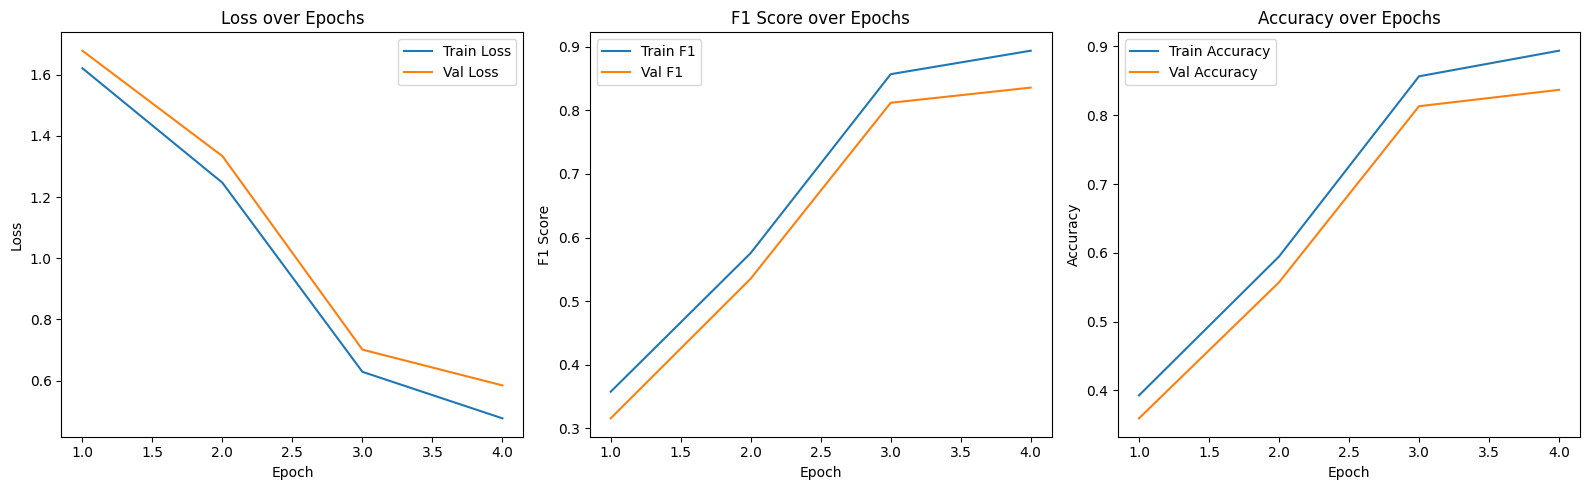

In [14]:
import matplotlib.pyplot as plt

# train_log y val_log deben ser listas de diccionarios con claves: 'loss', 'f1', 'accuracy'
# Ejemplo: train_log = [{'loss': ..., 'f1': ..., 'accuracy': ...}, ...]

# Extraer valores por métrica
train_loss = [stat['loss'] for stat in train_log]
val_loss = [stat['loss'] for stat in val_log]

train_f1 = [stat['f1'] for stat in train_log]
val_f1 = [stat['f1'] for stat in val_log]

train_acc = [stat['accuracy'] for stat in train_log]
val_acc = [stat['accuracy'] for stat in val_log]

epochs = range(1, len(train_log) + 1)

# Crear visualizaciones
plt.figure(figsize=(16, 5))

# Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# F1 Score
plt.subplot(1, 3, 2)
plt.plot(epochs, train_f1, label='Train F1')
plt.plot(epochs, val_f1, label='Val F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Score over Epochs')
plt.legend()

# Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


## Attention Visualizer

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import numpy as np

def colorize(words, color_array):
    """
    View words as conditional color
    """
    cmap = plt.get_cmap('Reds')
    template = '<span class="barcode"; style="color: black; background-color: {}">{}</span>'
    colored_string = ''
    for word, color in zip(words, color_array):
        hex_color = matplotlib.colors.rgb2hex(cmap(color)[:3])
        colored_string += template.format(hex_color, '&nbsp' + word + '&nbsp')
    return colored_string

def display_attention_for_user(attn_by_doc, pred_list, user_idx, num_top_tweets=5, label_map=None):
    """
    Show top tweets for each user and their attention scores
    
    - attn_by_doc: lista de documentos. Cada documento es lista de tweets [(word, score), ...].
    - pred_list: lista de predicciones.
    - user_idx: índice del usuario que quieres visualizar.
    - label_map: opcional, para traducir índice a string (ej. {0: 'Argentina', 1: 'Chile', ...}).
    """
    user_doc = attn_by_doc[user_idx]
    tweet_att_scores = [np.mean([s for _, s in tweet]) for tweet in user_doc]
    top_tweet_idxs = np.argsort(tweet_att_scores)[-num_top_tweets:][::-1]  # top tweets

    print(f"Predicted nationality: {label_map[pred_list[user_idx]] if label_map else pred_list[user_idx]}")
    print("")
    for idx in top_tweet_idxs:
        tweet = user_doc[idx]
        words = [w for w, s in tweet]
        scores = [s for w, s in tweet]
        print(f"Tweet {idx}:")
        display(HTML(colorize(words, scores)))


In [35]:
display_attention_for_user(
    attn_by_doc=val_log[3]['attn_by_doc'], 
    pred_list=val_log[3]['pred_list'], 
    user_idx=16, 
    num_top_tweets=15,
    label_map={0: 'Argentina', 1: 'Chile', 2: 'Colombia', 3: 'España', 4: 'México', 5: 'Perú', 6: 'Venezuela'}
)

Predicted nationality: México
Tweet 0:


Tweet 3:


Tweet 2:


Tweet 7:


Tweet 1:


...

Tweet 6:


Tweet 9:


Tweet 12:


Tweet 17:


Tweet 22:
